In [155]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats  # 과학용 계산 라이브러리
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML/diabetes.csv", index_col=0)
df = df.drop('Outcome', axis=1)
print(df)

             Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Pregnancies                                                         
6                148             72             35        0  33.6   
1                 85             66             29        0  26.6   
8                183             64              0        0  23.3   
1                 89             66             23       94  28.1   
0                137             40             35      168  43.1   
...              ...            ...            ...      ...   ...   
10               101             76             48      180  32.9   
2                122             70             27        0  36.8   
5                121             72             23      112  26.2   
1                126             60              0        0  30.1   
1                 93             70             31        0  30.4   

             DiabetesPedigreeFunction  Age  
Pregnancies                                 
6           

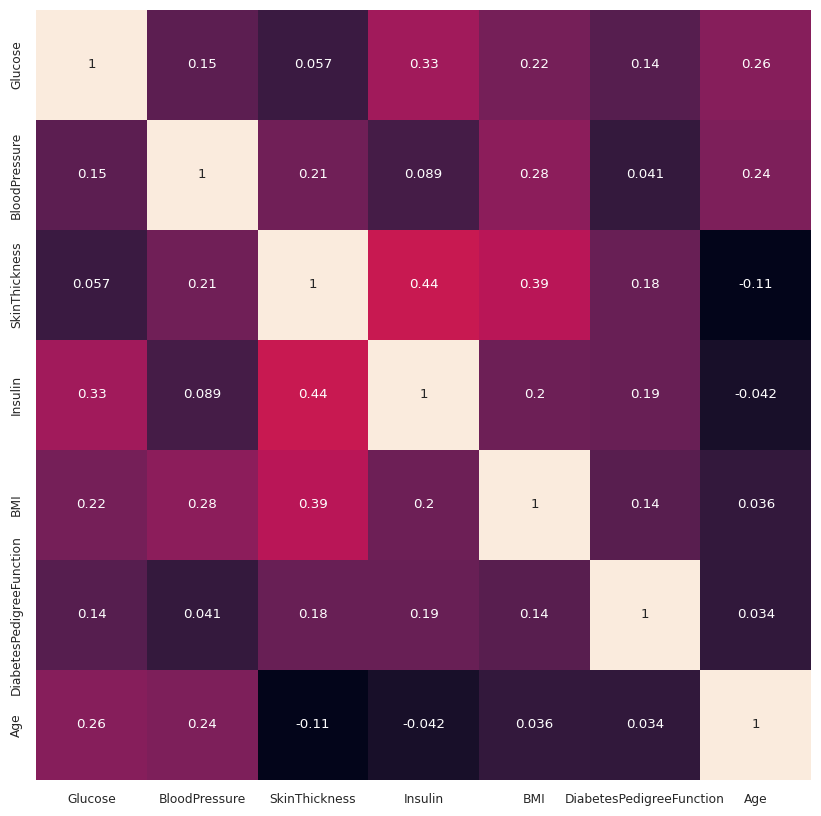

In [156]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# Insulin - SkinThickness의 상관 관계 : 0.44
# BMI - SkinThickness의 상관 관계 : 0.39
# Insulin - Glucose의 상관 관계 : 0.33

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [158]:
X = df.drop('BMI',axis=1)
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,
6,148,72,35,0,0.627,50
1,85,66,29,0,0.351,31
8,183,64,0,0,0.672,32
1,89,66,23,94,0.167,21
0,137,40,35,168,2.288,33


In [159]:
y = df['BMI']
y.head()

,BMI
Pregnancies,
6,33.6
1,26.6
8,23.3
1,28.1
0,43.1


In [160]:
#--------------
# 원-핫 인코딩
#--------------
# Y = pd.get_dummies(y).values

In [147]:
# 데이터를 훈련용과 테스트용으로 분할

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 0)

In [161]:
# 스케일러 생성
scaler = StandardScaler()

# 훈련 데이터로만 fit하고 transform
X_train = scaler.fit_transform(X_train)

# 테스트 데이터는 transform만 적용
X_test = scaler.transform(X_test)

In [162]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 6), (614,), (154, 6), (154,))

In [163]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()
model.add(Dense(8,input_shape=(X_train.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,905 (26.97 KB)

 Trainable params: 6,905 (26.97 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
N_EPOCHS = 50

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1048.1741 - mse: 1048.1741 - val_loss: 742.3223 - val_mse: 742.3223
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 669.5994 - mse: 669.5994 - val_loss: 296.8212 - val_mse: 296.8212
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 240.2667 - mse: 240.2667 - val_loss: 128.6428 - val_mse: 128.6428
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 121.6421 - mse: 121.6421 - val_loss: 110.3355 - val_mse: 110.3355
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 113.8126 - mse: 113.8126 - val_loss: 102.8856 - val_mse: 102.8856
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 104.8969 - mse: 104.8969 - val_loss: 90.0657 - val_mse: 90.0657
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 79.5209 - mse: 79.5209 - val_loss: 79.6409 - val_mse: 79.6409
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 83.6279 - mse: 83.6279 - val_loss: 72.2597 - val_mse: 72.2597
Epoch 9/50
20/2

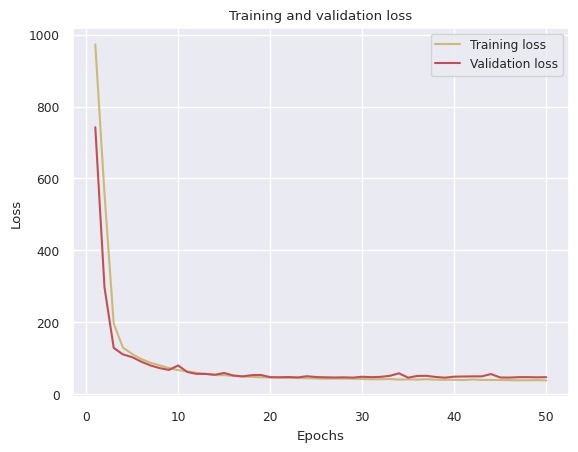

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [166]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 46.4084 - mse: 46.4084


[46.98451614379883, 46.98451614379883]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 6.8545
R-squared (R²): 0.2084


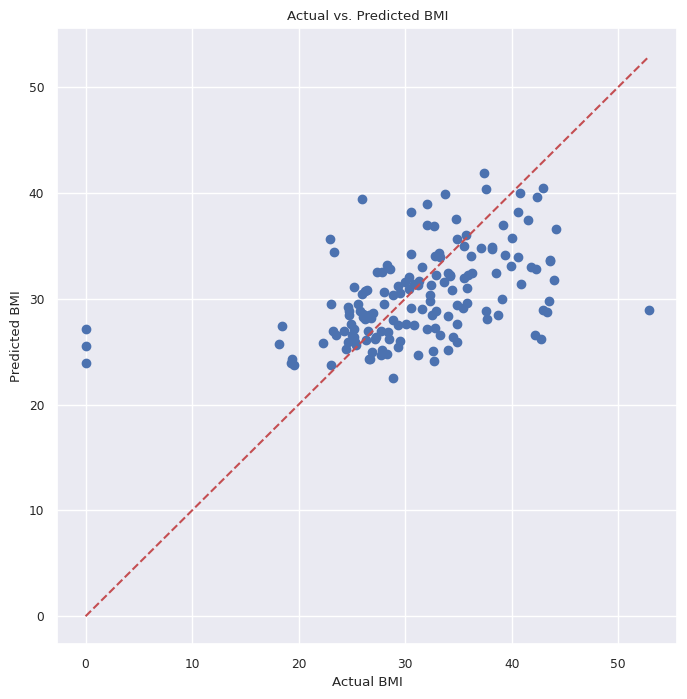

In [167]:
from sklearn.metrics import r2_score, mean_squared_error

# y_test는 1차원 배열이어야 하므로, 필요시 .ravel()을 사용
y_pred = model.predict(X_test).ravel()

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.4f}')

# R² 계산
r2 = r2_score(y_test, y_pred)
print(f'R-squared (R²): {r2:.4f}')


# 실제값 vs 예측값 시각화
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs. Predicted BMI")
# 추세선(y=x) 추가
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()